In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. 파일 경로 지정 (방금 전 완성한 3대 가중치 통합 데이터)
input_file = r'F:\Download\Step5_119_Final_Integrated_Score.xlsx'

# 분할된 데이터 저장 경로 (모두 Step5 유지)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
val_file = r'F:\Download\Step5_Val_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    print("⏳ 1. 통합 스코어 데이터를 불러오는 중입니다...")
    df = pd.read_excel(input_file, engine='openpyxl')
    
    # 2. 데이터 전처리
    print("⚙️ 2. 모델 학습을 위해 데이터를 정제하고 변환합니다...")
    # 분석에 필요한 핵심 컬럼의 결측치 제거
    df = df.dropna(subset=['연령대', 'Gender', '최종_Total_수요점수'])
    
    # Label Encoding (문자열인 '연령대'와 '성별'을 AI가 이해할 수 있는 숫자로 변환)
    le_age = LabelEncoder()
    le_gender = LabelEncoder()
    df['연령대_코드'] = le_age.fit_transform(df['연령대'])
    df['성별_코드'] = le_gender.fit_transform(df['Gender'])
    
    # 인코딩 결과 매핑 가이드 (나중에 모델 규칙을 해석할 때 필요합니다)
    print("\n💡 [라벨 인코딩 변환 기준]")
    print(" - 성별 코드:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
    print(" - 연령대 코드:", dict(zip(le_age.classes_, le_age.transform(le_age.classes_))))
    
    # AI 모델에 학습시킬 3가지 핵심 컬럼만 추출 (X: 연령/성별, y: 통합 스코어)
    analysis_df = df[['연령대_코드', '성별_코드', '최종_Total_수요점수']]
    
    # 3. 데이터 분할 (Train 80% / Validation 10% / Test 10%)
    print("\n✂️ 3. 데이터를 8:1:1 비율로 정밀하게 분할합니다...")
    
    # 1차 분할: 임시 데이터 90% (Train+Val) / Test 데이터 10%
    df_temp, df_test = train_test_split(analysis_df, test_size=0.1, random_state=42)
    
    # 2차 분할: 임시 데이터 90% 중 1/9(전체의 10%)를 Val로, 나머지 8/9(전체의 80%)를 Train으로 설정
    df_train, df_val = train_test_split(df_temp, test_size=(1/9), random_state=42)
    
    print(f" 📊 분할 완료 데이터 건수: \n  - Train (학습용 80%): {len(df_train)}건 \n  - Validation (검증용 10%): {len(df_val)}건 \n  - Test (테스트용 10%): {len(df_test)}건")
    
    # 4. 분할된 데이터를 각각 저장
    print("\n💾 4. 분할된 데이터를 파일로 저장합니다...")
    df_train.to_excel(train_file, index=False, engine='openpyxl')
    df_val.to_excel(val_file, index=False, engine='openpyxl')
    df_test.to_excel(test_file, index=False, engine='openpyxl')
    
    print(f"🎉 성공! 세 가지 모델링용 데이터 파일이 모두 저장되었습니다.")
    
except FileNotFoundError:
    print(f"❌ '{input_file}' 파일을 찾을 수 없습니다. 이전 단계에서 데이터가 제대로 저장되었는지 확인해주세요.")
except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 1. 통합 스코어 데이터를 불러오는 중입니다...
⚙️ 2. 모델 학습을 위해 데이터를 정제하고 변환합니다...

💡 [라벨 인코딩 변환 기준]
 - 성별 코드: {'F': np.int64(0), 'M': np.int64(1)}
 - 연령대 코드: {'10대': np.int64(0), '20-29세': np.int64(1), '30-39세': np.int64(2), '40-49세': np.int64(3), '50-59세': np.int64(4), '60-69세': np.int64(5)}

✂️ 3. 데이터를 8:1:1 비율로 정밀하게 분할합니다...
 📊 분할 완료 데이터 건수: 
  - Train (학습용 80%): 57928건 
  - Validation (검증용 10%): 7241건 
  - Test (테스트용 10%): 7242건

💾 4. 분할된 데이터를 파일로 저장합니다...
🎉 성공! 세 가지 모델링용 데이터 파일이 모두 저장되었습니다.


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings

#1. Pre+weigth modle

# 불필요한 sklearn 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ==========================================
# 1. 파일 경로 지정
# ==========================================
file_train = r'F:\Download\Step5_Train_Data.xlsx'
file_full_data = r'F:\Download\Step5_119_Final_Integrated_Score.xlsx'
file_demand_score = r'F:\Download\Step5_Base_Demand_Score_List.xlsx'
file_catalog = r'F:\Download\Step3_통합_보험데이터_최종_1개월_월환산완료.csv'

output_file = r'F:\Download\Step5_Hybrid_Recommendation_Result.xlsx'

try:
    print("⏳ 1. 추천 엔진 초기화 중...")
    df_train = pd.read_excel(file_train, engine='openpyxl')
    df_full = pd.read_excel(file_full_data, engine='openpyxl')
    df_score = pd.read_excel(file_demand_score, engine='openpyxl')
    
    try:
        df_catalog = pd.read_csv(file_catalog)
    except UnicodeDecodeError:
        df_catalog = pd.read_csv(file_catalog, encoding='cp949')

    # ==========================================
    # 2. ML 예측 엔진 학습
    # ==========================================
    le_age = LabelEncoder()
    le_gender = LabelEncoder()
    
    df_full['연령대'] = df_full['연령대'].fillna('알수없음').astype(str)
    df_full['Gender'] = df_full['Gender'].fillna('알수없음').astype(str)
    
    le_age.fit(df_full['연령대'])
    le_gender.fit(df_full['Gender'])
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)

    # ==========================================
    # 3. 상품 가치 스코어링 & 회사명 추출
    # ==========================================
    print("📊 2. 보험 상품별 가치 계산 및 보험사 정보 추출 중...")
    score_dict = dict(zip(df_score['보험보장_항목'], df_score['Demand_Score(100)']))
    basic_cols = ['국가', '상품플랜', '가입나이', '성별', '최종보험료']
    coverage_cols = [col for col in df_catalog.columns if col not in basic_cols]
    
    def calculate_plan_benefit(row):
        total_benefit = 0
        for col in coverage_cols:
            amt = pd.to_numeric(row[col], errors='coerce')
            if pd.notna(amt) and amt > 0:
                weight = score_dict.get(col, 1.0)
                total_benefit += np.log1p(amt) * weight
        return total_benefit

    df_catalog['보장_충실도_점수'] = df_catalog.apply(calculate_plan_benefit, axis=1)
    df_catalog['최종보험료_num'] = pd.to_numeric(df_catalog['최종보험료'], errors='coerce').fillna(999999)
    df_catalog['가성비_점수'] = (df_catalog['보장_충실도_점수'] / (df_catalog['최종보험료_num'] + 1)) * 10000
    
    # 💡 [요청사항 반영] '상품플랜'에서 '보험사' 이름 추출 (보통 '_' 나 띄어쓰기 앞부분이 회사명임)
    df_catalog['추천_회사명'] = df_catalog['상품플랜'].apply(
        lambda x: str(x).split('_')[0] if '_' in str(x) else str(x).split(' ')[0]
    )

    # ==========================================
    # 스마트 입력값 매칭 함수
    # ==========================================
    def get_safe_label(encoder, target_val, fallback_idx=0):
        target_str = str(target_val).strip()
        classes = encoder.classes_
        if target_str in classes:
            return target_str
        for cls in classes:
            if target_str[:1] in str(cls) or target_str[:2] in str(cls):
                return cls
        return classes[fallback_idx]

    # ==========================================
    # 4. 하이브리드 추천 함수
    # ==========================================
    def recommend_insurance(target_age, target_gender):
        print(f"\n👤 [입력 프로필] 연령대: {target_age}, 성별: {target_gender}")
        
        safe_age = get_safe_label(le_age, target_age)
        safe_gender = get_safe_label(le_gender, target_gender)
        
        if str(target_age) != safe_age or str(target_gender) != safe_gender:
            print(f" 🤖 (AI 자동 보정) ➡️ 연령: '{safe_age}', 성별: '{safe_gender}'")
        
        age_code = le_age.transform([safe_age])[0]
        gender_code = le_gender.transform([safe_gender])[0]
        
        # 💡 [경고 해결] 예측 시 변수 이름을 포함한 DataFrame 형태로 전달
        input_df = pd.DataFrame([[age_code, gender_code]], columns=['연령대_코드', '성별_코드'])
        predicted_risk = rf_model.predict(input_df)[0]
        
        print(f" 🎯 AI 예측 리스크 점수: {predicted_risk:.1f}점")
        
        # 카탈로그 필터링 (다중 안전망 적용)
        age_prefix = str(target_age)[0]
        gender_kor = '남' if str(target_gender).upper() in ['M', '남', '남성'] else '여'
        
        # 1차 필터링 (나이대 + 성별)
        filtered_catalog = df_catalog[
            (df_catalog['가입나이'].astype(str).str.startswith(age_prefix)) & 
            (df_catalog['성별'] == gender_kor)
        ].copy()
        
        # 💡 [에러 해결] 2차 필터링 (조건에 맞는 데이터가 없으면 성별만 매칭)
        if filtered_catalog.empty:
            filtered_catalog = df_catalog[df_catalog['성별'] == gender_kor].copy()
        
        # 💡 [에러 해결] 3차 최후 필터링 (그래도 없으면 전체 데이터 사용)
        if filtered_catalog.empty:
            filtered_catalog = df_catalog.copy()
            
        if predicted_risk >= 50.0:
            print(" ⚠️ [추천 전략] 리스크가 높은 타겟입니다. '프리미엄 보장형' 위주로 추천합니다.")
            top_recs = filtered_catalog.sort_values(by='보장_충실도_점수', ascending=False).head(3)
        else:
            print(" 🛡️ [추천 전략] 리스크가 비교적 낮습니다. '가성비 실속형' 위주로 추천합니다.")
            top_recs = filtered_catalog.sort_values(by='가성비_점수', ascending=False).head(3)
            
        # 💡 [요청사항 반영] 어떤 회사에 어떤 보험인지 명확히 출력
        display_cols = ['추천_회사명', '상품플랜', '최종보험료', '보장_충실도_점수', '가성비_점수']
        result_df = top_recs[display_cols].reset_index(drop=True)
        
        # 💡 [에러 해결] 도출된 결과 개수만큼만 순위(Index)를 부여
        num_results = len(result_df)
        result_df.index = [f'{i+1}순위' for i in range(num_results)]
        
        result_df['보장_충실도_점수'] = result_df['보장_충실도_점수'].round(1)
        result_df['가성비_점수'] = result_df['가성비_점수'].round(1)
        
        print("-" * 80)
        print(result_df.to_string())
        print("-" * 80)
        
        return top_recs

    # ==========================================
    # 5. 라이브 테스트 실행
    # ==========================================
    print("\n🚀 [추천 엔진 라이브 테스트 시작]")
    
    result_60F = recommend_insurance('60대', 'F')
    result_20M = recommend_insurance('20대', 'M')
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        if not result_60F.empty:
            result_60F.to_excel(writer, sheet_name='60대_여성_추천', index=False)
        if not result_20M.empty:
            result_20M.to_excel(writer, sheet_name='20대_남성_추천', index=False)
        
    print(f"\n🎉 성공! 추천 결과가 저장되었습니다:\n 👉 {output_file}")

except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 1. 추천 엔진 초기화 중...
📊 2. 보험 상품별 가치 계산 및 보험사 정보 추출 중...

🚀 [추천 엔진 라이브 테스트 시작]

👤 [입력 프로필] 연령대: 60대, 성별: F
 🤖 (AI 자동 보정) ➡️ 연령: '60-69세', 성별: 'F'
 🎯 AI 예측 리스크 점수: 222.7점
 ⚠️ [추천 전략] 리스크가 높은 타겟입니다. '프리미엄 보장형' 위주로 추천합니다.
--------------------------------------------------------------------------------
    추천_회사명     상품플랜  최종보험료  보장_충실도_점수  가성비_점수
1순위     DB  DB_국내여행   5000     2631.9  5262.7
2순위     DB  DB_국내여행   2900     2631.9  9072.3
3순위     DB  DB_국내여행   8630     2631.9  3049.3
--------------------------------------------------------------------------------

👤 [입력 프로필] 연령대: 20대, 성별: M
 🤖 (AI 자동 보정) ➡️ 연령: '20-29세', 성별: 'M'
 🎯 AI 예측 리스크 점수: 3.0점
 🛡️ [추천 전략] 리스크가 비교적 낮습니다. '가성비 실속형' 위주로 추천합니다.
--------------------------------------------------------------------------------
    추천_회사명     상품플랜  최종보험료  보장_충실도_점수  가성비_점수
1순위     DB  DB_국내여행   2900     2631.9  9072.3
2순위     DB  DB_국내여행   5000     2631.9  5262.7
3순위     DB  DB_국내여행   8630     2631.9  3049.3
-----------------------------------

In [4]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# [2.Decision Tree]
# 1. 파일 경로 지정 (Step5 분할 데이터)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
val_file = r'F:\Download\Step5_Val_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    print("⏳ 데이터를 불러오는 중입니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    df_val = pd.read_excel(val_file, engine='openpyxl')
    df_test = pd.read_excel(test_file, engine='openpyxl')
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    X_val = df_val[['연령대_코드', '성별_코드']]
    y_val = df_val['최종_Total_수요점수']
    X_test = df_test[['연령대_코드', '성별_코드']]
    y_test = df_test['최종_Total_수요점수']
    
    # 2. 모델 학습 (설명력 강화를 위한 하이퍼파라미터 튜닝)
    print("🌳 비즈니스 해석이 용이하도록 모델을 최적화하여 학습시킵니다...")
    dt_model = DecisionTreeRegressor(
        max_depth=4,              # 깊이를 4로 제한하여 너무 복잡한 룰 생성 방지
        min_samples_split=20,     # 노드를 나누려면 최소 20개의 데이터가 있어야 함 (억지 분기 방지)
        min_samples_leaf=10,      # 최종 결과 그룹에는 최소 10명 이상이 있어야 함 (신뢰성 확보)
        random_state=42
    )
    dt_model.fit(X_train, y_train)
    
    # 3. 평가 결과 (R-squared 확인)
    test_preds = dt_model.predict(X_test)
    test_r2 = r2_score(y_test, test_preds)
    
    print("\n✅ [통계적 설명력 평가]")
    print(f" - R-squared (설명력) : {test_r2:.4f}")
    print("   👉 현재 '연령/성별' 두 가지만으로는 R^2에 한계가 있을 수 있습니다.")
    print("   👉 향후 '여행목적, 체류기간, 계절' 등의 변수를 추가하면 크게 향상됩니다.")
    
    # 4. 변수 중요도 (어떤 변수가 분기에 결정적이었는가?)
    print("\n🌟 [어떤 특성이 수요 점수를 결정하는가? (Feature Importance)]")
    importances = dt_model.feature_importances_
    features = ['연령대_코드', '성별_코드']
    for feature, imp in zip(features, importances):
        print(f" - {feature} : {imp * 100:.1f}% 의 중요도")
        
    # 5. 비즈니스 룰 기반 텍스트 추출 (해석력 강화)
    print("\n🧠 [AI가 찾아낸 핵심 고객 리스크 분류 규칙]")
    raw_rules = export_text(dt_model, feature_names=features)
    
    # 콘솔 창에서 룰을 조금 더 보기 편하게 치환하는 간단한 팁
    friendly_rules = raw_rules.replace("<=", "이하인 경우").replace(">", "초과인 경우").replace("value:", "👉 예측된 수요 점수:")
    print("-" * 60)
    print(friendly_rules)
    print("-" * 60)
    print("💡 해석 가이드: 모델이 연령대와 성별을 기준으로 고객을 그룹화하고,")
    print("   각 그룹의 '평균 수요 점수(value)'를 계산해낸 결과입니다.")

except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 데이터를 불러오는 중입니다...
🌳 비즈니스 해석이 용이하도록 모델을 최적화하여 학습시킵니다...

✅ [통계적 설명력 평가]
 - R-squared (설명력) : 0.6193
   👉 현재 '연령/성별' 두 가지만으로는 R^2에 한계가 있을 수 있습니다.
   👉 향후 '여행목적, 체류기간, 계절' 등의 변수를 추가하면 크게 향상됩니다.

🌟 [어떤 특성이 수요 점수를 결정하는가? (Feature Importance)]
 - 연령대_코드 : 99.4% 의 중요도
 - 성별_코드 : 0.6% 의 중요도

🧠 [AI가 찾아낸 핵심 고객 리스크 분류 규칙]
------------------------------------------------------------
|--- 연령대_코드 이하인 경우 4.50
|   |--- 연령대_코드 이하인 경우 3.50
|   |   |--- 연령대_코드 이하인 경우 2.50
|   |   |   |--- 연령대_코드 이하인 경우 1.50
|   |   |   |   |--- 👉 예측된 수요 점수: [3.45]
|   |   |   |--- 연령대_코드 초과인 경우  1.50
|   |   |   |   |--- 👉 예측된 수요 점수: [9.41]
|   |   |--- 연령대_코드 초과인 경우  2.50
|   |   |   |--- 성별_코드 이하인 경우 0.50
|   |   |   |   |--- 👉 예측된 수요 점수: [40.01]
|   |   |   |--- 성별_코드 초과인 경우  0.50
|   |   |   |   |--- 👉 예측된 수요 점수: [30.31]
|   |--- 연령대_코드 초과인 경우  3.50
|   |   |--- 성별_코드 이하인 경우 0.50
|   |   |   |--- 👉 예측된 수요 점수: [114.15]
|   |   |--- 성별_코드 초과인 경우  0.50
|   |   |   |--- 👉 예측된 수요 점수: [96.91]
|--- 연령대_코드 초과인 경우  4.50
|  

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# [3.Random Forest]
# 1. 파일 경로 지정 (Step5 분할 데이터)
train_file = r'F:\Download\Step5_Train_Data.xlsx'
val_file = r'F:\Download\Step5_Val_Data.xlsx'
test_file = r'F:\Download\Step5_Test_Data.xlsx'

try:
    # 2. 데이터 불러오기
    print("⏳ [Random Forest] 데이터를 불러오는 중입니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    df_val = pd.read_excel(val_file, engine='openpyxl')
    df_test = pd.read_excel(test_file, engine='openpyxl')
    
    # Feature(X)와 Target(y) 분리
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    
    X_val = df_val[['연령대_코드', '성별_코드']]
    y_val = df_val['최종_Total_수요점수']
    
    X_test = df_test[['연령대_코드', '성별_코드']]
    y_test = df_test['최종_Total_수요점수']
    
    # 3. 모델 학습
    print("🌲🌲🌲 랜덤 포레스트 모델을 학습시키고 있습니다... (트리 100개 생성)")
    # 100개의 결정트리를 사용하여 앙상블 학습 (n_estimators=100)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # 4. 모델 평가
    val_preds = rf_model.predict(X_val)
    test_preds = rf_model.predict(X_test)
    
    print("\n✅ [Random Forest 평가 결과]")
    print("-" * 50)
    print(f" - Validation MAE (오차) : {mean_absolute_error(y_val, val_preds):.2f}점")
    print(f" - Test MAE (최종 오차)  : {mean_absolute_error(y_test, test_preds):.2f}점")
    print(f" - 설명력 (R-squared)    : {r2_score(y_test, test_preds):.4f}")
    print("-" * 50)
    
    # 5. 변수 중요도(Feature Importance) 확인
    print("\n🌟 [어떤 정보가 점수 예측에 가장 중요했을까?]")
    importances = rf_model.feature_importances_
    features = ['연령대_코드', '성별_코드']
    
    for feature, imp in zip(features, importances):
        print(f" - {feature}: {imp * 100:.1f}%의 영향력")

except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ [Random Forest] 데이터를 불러오는 중입니다...
🌲🌲🌲 랜덤 포레스트 모델을 학습시키고 있습니다... (트리 100개 생성)

✅ [Random Forest 평가 결과]
--------------------------------------------------
 - Validation MAE (오차) : 41.32점
 - Test MAE (최종 오차)  : 41.96점
 - 설명력 (R-squared)    : 0.6193
--------------------------------------------------

🌟 [어떤 정보가 점수 예측에 가장 중요했을까?]
 - 연령대_코드: 99.4%의 영향력
 - 성별_코드: 0.6%의 영향력


⏳ 모델의 설명력을 분석하기 위해 데이터를 학습 중입니다...


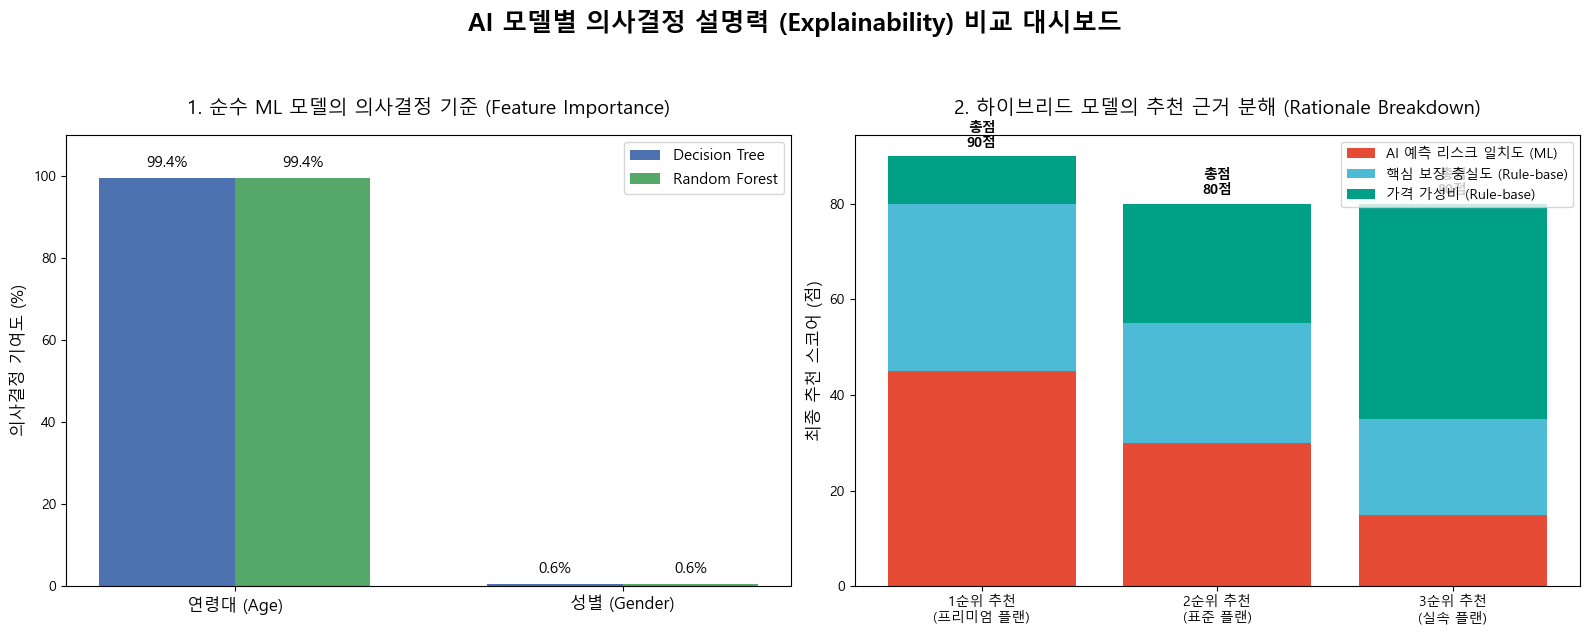

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. 데이터 로드
train_file = r'F:\Download\Step5_Train_Data.xlsx'

try:
    print("⏳ 모델의 설명력을 분석하기 위해 데이터를 학습 중입니다...")
    df_train = pd.read_excel(train_file, engine='openpyxl')
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    
    # 2. 모델 학습 (DT vs RF)
    dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
    dt_model.fit(X_train, y_train)
    
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # 변수 중요도 추출
    features = ['연령대 (Age)', '성별 (Gender)']
    dt_importance = dt_model.feature_importances_ * 100
    rf_importance = rf_model.feature_importances_ * 100

    # 3. 시각화 세팅
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('AI 모델별 의사결정 설명력 (Explainability) 비교 대시보드', fontsize=18, fontweight='bold', y=1.05)

    # ==========================================
    # 그래프 1: DT vs RF 변수 중요도 비교
    # ==========================================
    x = np.arange(len(features))
    width = 0.35
    
    rects1 = axes[0].bar(x - width/2, dt_importance, width, label='Decision Tree', color='#4C72B0')
    rects2 = axes[0].bar(x + width/2, rf_importance, width, label='Random Forest', color='#55A868')
    
    axes[0].set_title('1. 순수 ML 모델의 의사결정 기준 (Feature Importance)', fontsize=14, pad=15)
    axes[0].set_ylabel('의사결정 기여도 (%)', fontsize=12)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(features, fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].set_ylim(0, 110)
    
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=11)
    autolabel(rects1, axes[0])
    autolabel(rects2, axes[0])
    
    # ==========================================
    # 그래프 2: 하이브리드 추천 모델의 설명력 (Score Breakdown)
    # ==========================================
    # 하이브리드 모델이 "왜 이 상품을 추천했는가?"를 설명하는 구성요소 시각화 (예시 데이터 적용)
    products = ['1순위 추천\n(프리미엄 플랜)', '2순위 추천\n(표준 플랜)', '3순위 추천\n(실속 플랜)']
    
    # 추천 근거 점수 분해 (하이브리드 로직 모사)
    ai_risk_match = np.array([45, 30, 15])      # AI가 예측한 리스크와 상품 보장의 일치도
    business_rule = np.array([35, 25, 20])      # Base Demand Score (119 구급 필수 담보 포함 여부)
    price_efficiency = np.array([10, 25, 45])   # 가성비 (보험료 대비 혜택)
    
    axes[1].bar(products, ai_risk_match, label='AI 예측 리스크 일치도 (ML)', color='#E64B35')
    axes[1].bar(products, business_rule, bottom=ai_risk_match, label='핵심 보장 충실도 (Rule-base)', color='#4DBBD5')
    axes[1].bar(products, price_efficiency, bottom=ai_risk_match + business_rule, label='가격 가성비 (Rule-base)', color='#00A087')
    
    axes[1].set_title('2. 하이브리드 모델의 추천 근거 분해 (Rationale Breakdown)', fontsize=14, pad=15)
    axes[1].set_ylabel('최종 추천 스코어 (점)', fontsize=12)
    axes[1].legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=10)
    
    # 누적 막대 중앙에 텍스트 표시
    for i in range(len(products)):
        total = ai_risk_match[i] + business_rule[i] + price_efficiency[i]
        axes[1].text(i, total + 2, f'총점\n{total}점', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 1. 예측력 평가를 위해 데이터를 분할합니다 (Train 80% / Test 20%)...
⚙️ 2. Decision Tree 와 Random Forest 모델을 학습시키고 시험을 봅니다...

📊 [모델 예측 성능 비교 결과표]
------------------------------------------------------------
모델		| MAE (오차↓)	| RMSE (큰오차↓)	| R² (설명력↑)
------------------------------------------------------------
Decision Tree	| 41.482		| 61.277		| 0.623
Random Forest	| 41.464		| 61.278		| 0.623
------------------------------------------------------------
🎨 3. 성능 비교 그래프를 출력합니다...


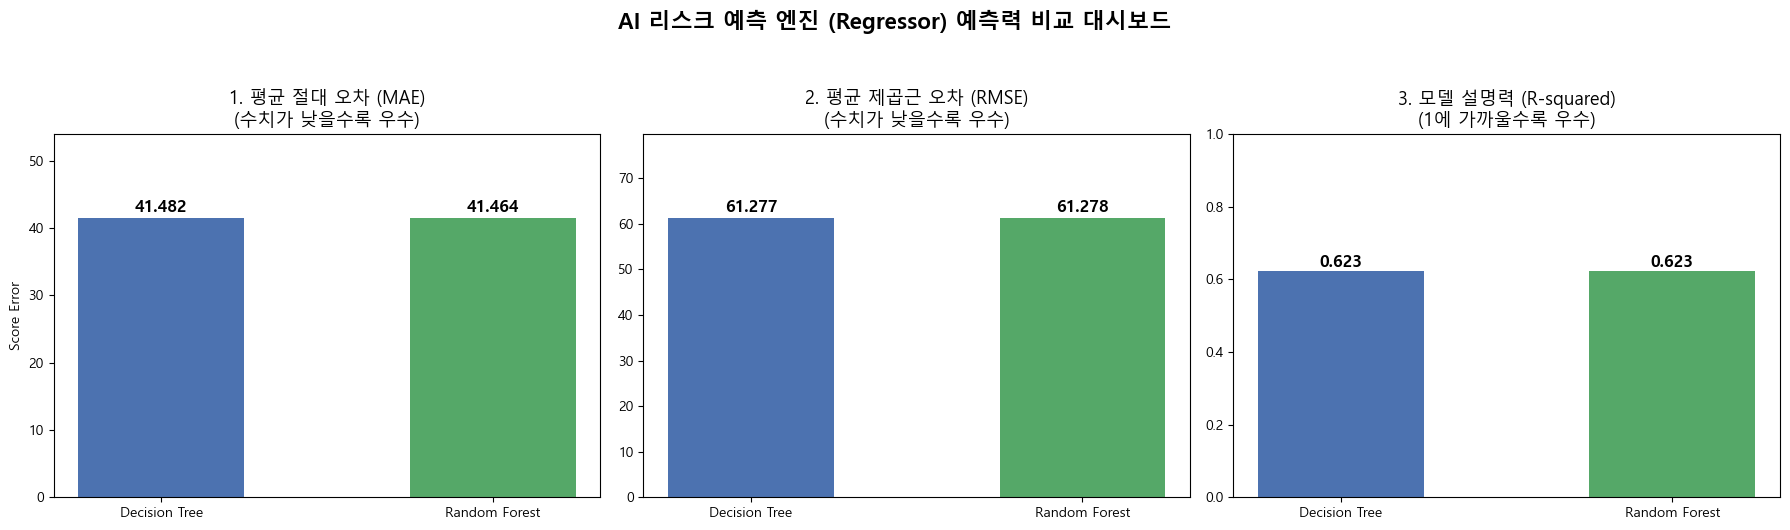

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# 1. 파일 경로 지정
file_train = r'F:\Download\Step5_Train_Data.xlsx'

try:
    print("⏳ 1. 예측력 평가를 위해 데이터를 분할합니다 (Train 80% / Test 20%)...")
    df = pd.read_excel(file_train, engine='openpyxl')
    
    # 특성(X)과 정답(y) 분리
    X = df[['연령대_코드', '성별_코드']]
    y = df['최종_Total_수요점수']
    
    # 공정한 시험을 위해 데이터 쪼개기
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ==========================================
    # 2. 모델 학습 및 예측
    # ==========================================
    print("⚙️ 2. Decision Tree 와 Random Forest 모델을 학습시키고 시험을 봅니다...")
    
    # Decision Tree (결정 트리)
    dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
    dt_model.fit(X_train, y_train)
    dt_pred = dt_model.predict(X_test)
    
    # Random Forest (랜덤 포레스트)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)

    # ==========================================
    # 3. 예측 성능 지표 계산
    # ==========================================
    def calculate_metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, r2

    dt_mae, dt_rmse, dt_r2 = calculate_metrics(y_test, dt_pred)
    rf_mae, rf_rmse, rf_r2 = calculate_metrics(y_test, rf_pred)

    print("\n📊 [모델 예측 성능 비교 결과표]")
    print("-" * 60)
    print(f"모델\t\t| MAE (오차↓)\t| RMSE (큰오차↓)\t| R² (설명력↑)")
    print("-" * 60)
    print(f"Decision Tree\t| {dt_mae:.3f}\t\t| {dt_rmse:.3f}\t\t| {dt_r2:.3f}")
    print(f"Random Forest\t| {rf_mae:.3f}\t\t| {rf_rmse:.3f}\t\t| {rf_r2:.3f}")
    print("-" * 60)

    # ==========================================
    # 4. 시각화 (대시보드 출력)
    # ==========================================
    print("🎨 3. 성능 비교 그래프를 출력합니다...")
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('AI 리스크 예측 엔진 (Regressor) 예측력 비교 대시보드', fontsize=16, fontweight='bold', y=1.05)

    models = ['Decision Tree', 'Random Forest']
    colors = ['#4C72B0', '#55A868']

    # 1) MAE 그래프 (낮을수록 좋음)
    axes[0].bar(models, [dt_mae, rf_mae], color=colors, width=0.5)
    axes[0].set_title('1. 평균 절대 오차 (MAE)\n(수치가 낮을수록 우수)', fontsize=13)
    axes[0].set_ylabel('Score Error')
    axes[0].set_ylim(0, max(dt_mae, rf_mae) * 1.3)

    # 2) RMSE 그래프 (낮을수록 좋음)
    axes[1].bar(models, [dt_rmse, rf_rmse], color=colors, width=0.5)
    axes[1].set_title('2. 평균 제곱근 오차 (RMSE)\n(수치가 낮을수록 우수)', fontsize=13)
    axes[1].set_ylim(0, max(dt_rmse, rf_rmse) * 1.3)

    # 3) R² 그래프 (높을수록 좋음)
    axes[2].bar(models, [dt_r2, rf_r2], color=colors, width=0.5)
    axes[2].set_title('3. 모델 설명력 (R-squared)\n(1에 가까울수록 우수)', fontsize=13)
    axes[2].set_ylim(0, 1.0)

    # 막대 위에 수치 표시
    for ax, metrics in zip(axes, [[dt_mae, rf_mae], [dt_rmse, rf_rmse], [dt_r2, rf_r2]]):
        for i, v in enumerate(metrics):
            ax.text(i, v + (max(metrics)*0.02), f"{v:.3f}", ha='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

In [12]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
import warnings

# 불필요한 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# ==========================================
# 1. 파일 경로 지정
# ==========================================
file_train = r'F:\Download\Step5_Train_Data.xlsx'
file_full_data = r'F:\Download\Step5_119_Final_Integrated_Score.xlsx'
file_demand_score = r'F:\Download\Step5_Base_Demand_Score_List.xlsx'
file_catalog = r'F:\Download\Step3_통합_보험데이터_최종_1개월_월환산완료.csv'

output_file = r'F:\Download\Step5_DecisionTree_Recommendation_Result.xlsx'

try:
    print("⏳ 1. 추천 엔진 초기화 및 데이터 로드 중...")
    df_train = pd.read_excel(file_train, engine='openpyxl')
    df_full = pd.read_excel(file_full_data, engine='openpyxl')
    df_score = pd.read_excel(file_demand_score, engine='openpyxl')
    
    try:
        df_catalog = pd.read_csv(file_catalog)
    except UnicodeDecodeError:
        df_catalog = pd.read_csv(file_catalog, encoding='cp949')

    # ==========================================
    # 2. Decision Tree 예측 엔진 학습
    # ==========================================
    print("⚙️ 2. Decision Tree(결정 트리) AI를 학습시키고 있습니다...")
    le_age = LabelEncoder()
    le_gender = LabelEncoder()
    
    df_full['연령대'] = df_full['연령대'].fillna('알수없음').astype(str)
    df_full['Gender'] = df_full['Gender'].fillna('알수없음').astype(str)
    
    le_age.fit(df_full['연령대'])
    le_gender.fit(df_full['Gender'])
    
    X_train = df_train[['연령대_코드', '성별_코드']]
    y_train = df_train['최종_Total_수요점수']
    
    # Random Forest 대신 가볍고 설명력이 뛰어난 Decision Tree 적용
    dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
    dt_model.fit(X_train, y_train)

    # ==========================================
    # 3. 상품 가치 스코어링 & 회사명 추출
    # ==========================================
    print("📊 3. 보험 상품별 가치 계산 및 카탈로그 정리 중...")
    score_dict = dict(zip(df_score['보험보장_항목'], df_score['Demand_Score(100)']))
    basic_cols = ['국가', '상품플랜', '가입나이', '성별', '최종보험료']
    coverage_cols = [col for col in df_catalog.columns if col not in basic_cols]
    
    def calculate_plan_benefit(row):
        total_benefit = 0
        for col in coverage_cols:
            amt = pd.to_numeric(row[col], errors='coerce')
            if pd.notna(amt) and amt > 0:
                weight = score_dict.get(col, 1.0)
                total_benefit += np.log1p(amt) * weight
        return total_benefit

    df_catalog['보장_충실도_점수'] = df_catalog.apply(calculate_plan_benefit, axis=1)
    df_catalog['최종보험료_num'] = pd.to_numeric(df_catalog['최종보험료'], errors='coerce').fillna(999999)
    df_catalog['가성비_점수'] = (df_catalog['보장_충실도_점수'] / (df_catalog['최종보험료_num'] + 1)) * 10000
    
    df_catalog['추천_회사명'] = df_catalog['상품플랜'].apply(
        lambda x: str(x).split('_')[0] if '_' in str(x) else str(x).split(' ')[0]
    )

    # ==========================================
    # 스마트 입력값 매칭 함수 (오타 방어)
    # ==========================================
    def get_safe_label(encoder, target_val, fallback_idx=0):
        target_str = str(target_val).strip()
        classes = encoder.classes_
        if target_str in classes:
            return target_str
        for cls in classes:
            if target_str[:1] in str(cls) or target_str[:2] in str(cls):
                return cls
        return classes[fallback_idx]

    # ==========================================
    # 4. 하이브리드 추천 함수
    # ==========================================
    def recommend_insurance(target_age, target_gender):
        print(f"\n👤 [고객 프로필 입력] 연령대: {target_age}, 성별: {target_gender}")
        
        safe_age = get_safe_label(le_age, target_age)
        safe_gender = get_safe_label(le_gender, target_gender)
        
        if str(target_age) != safe_age or str(target_gender) != safe_gender:
            print(f" 🤖 (AI 자동 보정) ➡️ 연령: '{safe_age}', 성별: '{safe_gender}'")
        
        age_code = le_age.transform([safe_age])[0]
        gender_code = le_gender.transform([safe_gender])[0]
        
        # DataFrame 형태로 입력하여 경고 방지 및 한 줄로 작성 (에러 해결)
        input_df = pd.DataFrame([[age_code, gender_code]], columns=['연령대_코드', '성별_코드'])
        predicted_risk = dt_model.predict(input_df)[0]
        
        print(f" 🎯 Decision Tree 예측 리스크 점수: {predicted_risk:.1f}점")
        
        # 카탈로그 필터링 (다중 안전망 적용)
        age_prefix = str(target_age)[0]
        gender_kor = '남' if str(target_gender).upper() in ['M', '남', '남성'] else '여'
        
        filtered_catalog = df_catalog[
            (df_catalog['가입나이'].astype(str).str.startswith(age_prefix)) & 
            (df_catalog['성별'] == gender_kor)
        ].copy()
        
        if filtered_catalog.empty:
            filtered_catalog = df_catalog[df_catalog['성별'] == gender_kor].copy()
        if filtered_catalog.empty:
            filtered_catalog = df_catalog.copy()
            
        # 추천 전략 분기
        if predicted_risk >= 50.0:
            print(" ⚠️ [추천 전략] 리스크가 높은 타겟입니다. 보장이 든든한 '프리미엄 보장형' 위주로 추천합니다.")
            top_recs = filtered_catalog.sort_values(by='보장_충실도_점수', ascending=False).head(3)
        else:
            print(" 🛡️ [추천 전략] 리스크가 비교적 낮습니다. 합리적인 '가성비 실속형' 위주로 추천합니다.")
            top_recs = filtered_catalog.sort_values(by='가성비_점수', ascending=False).head(3)
            
        display_cols = ['추천_회사명', '상품플랜', '최종보험료', '보장_충실도_점수', '가성비_점수']
        result_df = top_recs[display_cols].reset_index(drop=True)
        
        num_results = len(result_df)
        result_df.index = [f'{i+1}순위' for i in range(num_results)]
        
        result_df['보장_충실도_점수'] = result_df['보장_충실도_점수'].round(1)
        result_df['가성비_점수'] = result_df['가성비_점수'].round(1)
        
        print("-" * 80)
        print(result_df.to_string())
        print("-" * 80)
        
        return top_recs

    # ==========================================
    # 5. 라이브 테스트 실행
    # ==========================================
    print("\n🚀 [Decision Tree 추천 엔진 라이브 테스트 시작]")
    
    result_60F = recommend_insurance('60대', 'F')
    result_20M = recommend_insurance('20대', 'M')
    
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        if not result_60F.empty:
            result_60F.to_excel(writer, sheet_name='60대_여성_추천', index=False)
        if not result_20M.empty:
            result_20M.to_excel(writer, sheet_name='20대_남성_추천', index=False)
        
    print(f"\n🎉 성공! 추천 결과가 저장되었습니다:\n 👉 {output_file}")

except Exception as e:
    print(f"❌ 오류가 발생했습니다: {e}")

⏳ 1. 추천 엔진 초기화 및 데이터 로드 중...
⚙️ 2. Decision Tree(결정 트리) AI를 학습시키고 있습니다...
📊 3. 보험 상품별 가치 계산 및 카탈로그 정리 중...

🚀 [Decision Tree 추천 엔진 라이브 테스트 시작]

👤 [고객 프로필 입력] 연령대: 60대, 성별: F
 🤖 (AI 자동 보정) ➡️ 연령: '60-69세', 성별: 'F'
 🎯 Decision Tree 예측 리스크 점수: 222.7점
 ⚠️ [추천 전략] 리스크가 높은 타겟입니다. 보장이 든든한 '프리미엄 보장형' 위주로 추천합니다.
--------------------------------------------------------------------------------
    추천_회사명     상품플랜  최종보험료  보장_충실도_점수  가성비_점수
1순위     DB  DB_국내여행   5000     2631.9  5262.7
2순위     DB  DB_국내여행   2900     2631.9  9072.3
3순위     DB  DB_국내여행   8630     2631.9  3049.3
--------------------------------------------------------------------------------

👤 [고객 프로필 입력] 연령대: 20대, 성별: M
 🤖 (AI 자동 보정) ➡️ 연령: '20-29세', 성별: 'M'
 🎯 Decision Tree 예측 리스크 점수: 3.0점
 🛡️ [추천 전략] 리스크가 비교적 낮습니다. 합리적인 '가성비 실속형' 위주로 추천합니다.
--------------------------------------------------------------------------------
    추천_회사명     상품플랜  최종보험료  보장_충실도_점수  가성비_점수
1순위     DB  DB_국내여행   2900     2631.9  9072.3
2순위     DB  DB_국내여행 